Weight statistics:
Min            : 1.78086e-18
Max            : 7.67235e-03
Median         : 4.88890e-03
Mean           : 3.88454e-03
16–84 percentile: 3.66038e-07 – 6.16866e-03

Suggested thresholds:
Very loose (mask only zeros)        : 0.0
Loose  (~0.3 × median)              : 1.46667e-03
Recommended (~0.5 × median)         : 2.44445e-03
Strict (~0.7 × median)              : 3.42223e-03


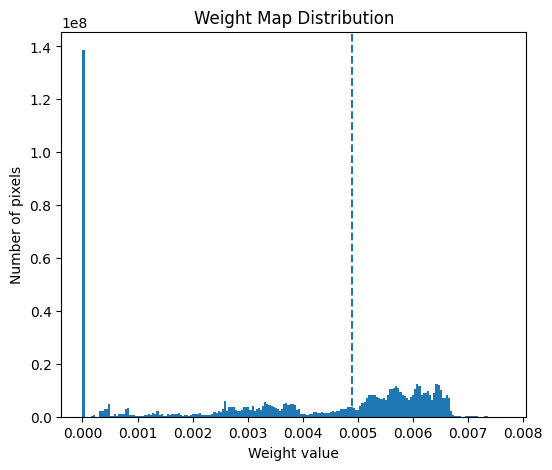

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


weight_file = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_Y.weight.fits.fz"


with fits.open(weight_file) as hdu:
    weight = hdu[1].data


if weight is None:
    raise ValueError("Weight data is None. Check FITS extension.")

# Remove zero pixels
valid = weight[weight > 0]

print("Weight statistics:")
print(f"Min            : {np.min(valid):.5e}")
print(f"Max            : {np.max(valid):.5e}")
print(f"Median         : {np.median(valid):.5e}")
print(f"Mean           : {np.mean(valid):.5e}")
print(f"16–84 percentile: {np.percentile(valid,16):.5e} – {np.percentile(valid,84):.5e}")

median = np.median(valid)

print("\nSuggested thresholds:")
print(f"Very loose (mask only zeros)        : 0.0")
print(f"Loose  (~0.3 × median)              : {0.3 * median:.5e}")
print(f"Recommended (~0.5 × median)         : {0.5 * median:.5e}")
print(f"Strict (~0.7 × median)              : {0.7 * median:.5e}")

plt.figure(figsize=(6,5))
plt.hist(valid.flatten(), bins=200)
plt.axvline(median, linestyle='--')
plt.xlabel("Weight value")
plt.ylabel("Number of pixels")
plt.title("Weight Map Distribution")
plt.show()


In [10]:
from astropy.io import fits

weight_file = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_Y.weight.fits.fz"

with fits.open(weight_file) as hdu:
    hdu.info()


Filename: /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_Y.weight.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU     47   (32000, 32000)   float32   


In [12]:
import os
import numpy as np
from astropy.io import fits

# -----------------------------
# USER PATHS
# -----------------------------

BASE_PATH = "/Users/aishwarya/Desktop/CDFS/Files/CDFS"
OUTPUT_DIR = "/Users/aishwarya/Desktop/new_cdfs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# FILES
# -----------------------------

files = [
    {
        "science": f"{BASE_PATH}/CDFS_i.fits.fz",
        "weight":  f"{BASE_PATH}/CDFS_i.weight.fits.fz",
        "threshold": 0.4,
        "outname": "CDFS_i_weightmasked.fits"
    },
    {
        "science": f"{BASE_PATH}/CDFS_z.fits.fz",
        "weight":  f"{BASE_PATH}/CDFS_z.weight.fits.fz",
        "threshold": 0.17,
        "outname": "CDFS_z_weightmasked.fits"
    },
    {
        "science": f"{BASE_PATH}/CDFS_Y.fits.fz",
        "weight":  f"{BASE_PATH}/CDFS_Y.weight.fits.fz",
        "threshold": 0.0024,
        "outname": "CDFS_Y_weightmasked.fits"
    }
]

# -----------------------------
# STEP 1: BUILD MASKS
# -----------------------------

masks = []

for file in files:

    with fits.open(file["weight"]) as hdu:
        for ext in hdu:
            if ext.data is not None:
                weight_data = ext.data
                break

    mask = weight_data >= file["threshold"]
    masks.append(mask)

# -----------------------------
# STEP 2: MULTIPLY MASKS
# -----------------------------

combined_mask = masks[0] & masks[1] & masks[2]

# -----------------------------
# STEP 3: APPLY TO ALL IMAGES
# -----------------------------

for file in files:

    print(f"\nProcessing {file['science']}")

    with fits.open(file["science"]) as hdu:
        for ext in hdu:
            if ext.data is not None:
                sci_data = ext.data
                header = ext.header
                break

    masked_image = sci_data.copy()
    masked_image[~combined_mask] = np.nan

    output_path = os.path.join(OUTPUT_DIR, file["outname"])
    fits.writeto(output_path, masked_image, header, overwrite=True)

    print(f"Saved to {output_path}")

print("\nAll images masked with identical footprint.")


Processing /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.fits.fz
Saved to /Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked.fits

Processing /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.fits.fz
Saved to /Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked.fits

Processing /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_Y.fits.fz
Saved to /Users/aishwarya/Desktop/new_cdfs/CDFS_Y_weightmasked.fits

All images masked with identical footprint.


# Mask Bright Pannstar stars

In [22]:
import pandas as pd

csv_file = "/Users/aishwarya/Desktop/new_cdfs/PS1_CDFS_Test1_aishusps.csv"

df = pd.read_csv(csv_file)
for c in df.columns:
    if "ra" in c.lower() or "dec" in c.lower():
        print(c)

randomStackObjID
gra
gdec
graErr
gdecErr
gnFrames
rra
rdec
rraErr
rdecErr
rApMag
rApMagErr
rnFrames
ira
idec
iraErr
idecErr
inFrames
zra
zdec
zraErr
zdecErr
znFrames
yra
ydec
yraErr
ydecErr
ynFrames


# MAsk with only science files

In [ ]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# --------------------------------------------------
# FILES
# --------------------------------------------------

catalog = "/Users/aishwarya/Desktop/new_cdfs/PS1_CDFS_Test1_aishusps.csv"

i_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked.fits"
z_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked.fits"
y_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_Y_weightmasked.fits"

images = {
    "i": i_image,
    "z": z_image,
    "y": y_image
}

# --------------------------------------------------
# MAG LIMITS PER BAND
# --------------------------------------------------

mag_limits = {
    "i": 18,
    "z": 18,
    "y": 18
}

# --------------------------------------------------
# READ PAN-STARRS CATALOG
# --------------------------------------------------

df = pd.read_csv(catalog)

df.replace(-999, np.nan, inplace=True)

# --------------------------------------------------
# MAG → MASK SIZE
# --------------------------------------------------

def mask_radius_arcsec(m):

    if m < 10:
        return 60
    elif m < 14:
        return 20
    elif m < 16:
        return 10
    elif m < 18:
        return 6
    else:
        return 5


# --------------------------------------------------
# BUILD GLOBAL MASK
# --------------------------------------------------

print("Building combined mask...")

hdu = fits.open(i_image)
shape = hdu[0].data.shape
header = hdu[0].header
wcs = WCS(header)

pixscale = 0.27

ny, nx = shape

global_mask = np.zeros(shape, dtype=bool)

# --------------------------------------------------
# PROCESS EACH BAND
# --------------------------------------------------

for band in ["i", "z", "y"]:

    print("Processing band:", band)

    if band == "i":
        ra = df["ira"].values
        dec = df["idec"].values
        mag = df["iPSFMag"].values

    elif band == "z":
        ra = df["zra"].values
        dec = df["zdec"].values
        mag = df["zPSFMag"].values

    else:
        ra = df["yra"].values
        dec = df["ydec"].values
        mag = df["yPSFMag"].values

    valid = ~np.isnan(mag)
    ra = ra[valid]
    dec = dec[valid]
    mag = mag[valid]

    bright = mag < mag_limits[band]

    ra = ra[bright]
    dec = dec[bright]
    mag = mag[bright]

    coords = SkyCoord(ra*u.deg, dec*u.deg)

    xpix, ypix = wcs.world_to_pixel(coords)

    for i, (x, y, m) in enumerate(zip(xpix, ypix, mag)):

        if i % 500 == 0:
            print("Masked", i, "stars")

        r_arcsec = mask_radius_arcsec(m)

        r_pix = int(r_arcsec / pixscale)

        x0 = int(x)
        y0 = int(y)

        if x0 < 0 or x0 >= nx or y0 < 0 or y0 >= ny:
            continue

        x1 = max(0, x0 - r_pix)
        x2 = min(nx, x0 + r_pix)

        y1 = max(0, y0 - r_pix)
        y2 = min(ny, y0 + r_pix)

        yy, xx = np.ogrid[y1:y2, x1:x2]

        mask = (xx - x)**2 + (yy - y)**2 < r_pix**2

        global_mask[y1:y2, x1:x2] |= mask

# --------------------------------------------------
# APPLY FINAL MASK TO ALL IMAGES
# --------------------------------------------------

print("Applying mask to images...")

for band, img in images.items():

    hdu = fits.open(img)

    data = hdu[0].data
    header = hdu[0].header

    data[global_mask] = np.nan

    output = img.replace(".fits", "_brightstar_masked.fits")

    fits.writeto(output, data, header, overwrite=True)

    print("Saved:", output)

Building combined mask...
Processing band: i
Masked 0 stars
Masked 500 stars
Masked 1000 stars
Masked 1500 stars
Masked 2000 stars
Masked 2500 stars
Masked 3000 stars
Masked 3500 stars
Masked 4000 stars
Masked 4500 stars
Masked 5000 stars
Masked 5500 stars
Masked 6000 stars
Masked 6500 stars
Masked 7000 stars
Masked 7500 stars
Masked 8000 stars
Masked 8500 stars
Masked 9000 stars
Masked 9500 stars
Masked 10000 stars
Masked 10500 stars
Masked 11000 stars
Masked 11500 stars
Masked 12000 stars
Masked 12500 stars
Processing band: z
Masked 0 stars
Masked 500 stars
Masked 1000 stars
Masked 1500 stars
Masked 2000 stars
Masked 2500 stars
Masked 3000 stars
Masked 3500 stars
Masked 4000 stars
Masked 4500 stars
Masked 5000 stars
Masked 5500 stars
Masked 6000 stars
Masked 6500 stars
Masked 7000 stars
Masked 7500 stars
Masked 8000 stars
Masked 8500 stars
Masked 9000 stars
Masked 9500 stars
Masked 10000 stars
Masked 10500 stars
Masked 11000 stars
Masked 11500 stars
Masked 12000 stars
Masked 12500 st

TypeError: 'NoneType' object does not support item assignment

# Mask with weight files as well

In [13]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# --------------------------------------------------
# FILES
# --------------------------------------------------

catalog = "/Users/aishwarya/Desktop/new_cdfs/PS1_CDFS_Test1_aishusps.csv"

i_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked.fits"
i_weight = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight.fits.fz"

z_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked.fits"
z_weight = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.weight.fits.fz"

y_image = "/Users/aishwarya/Desktop/new_cdfs/CDFS_Y_weightmasked.fits"
y_weight = "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_y.weight.fits.fz"

images = {
    "i": i_image,
    "i_weight": i_weight,
    "z": z_image,
    "z_weight": z_weight,
    "y": y_image,
    "y_weight": y_weight
}

# --------------------------------------------------
# MAG LIMITS PER BAND
# --------------------------------------------------

mag_limits = {
    "i": 18,
    "z": 18,
    "y": 18
}

# --------------------------------------------------
# READ PAN-STARRS CATALOG
# --------------------------------------------------

df = pd.read_csv(catalog)
df.replace(-999, np.nan, inplace=True)

# --------------------------------------------------
# MAG → MASK SIZE
# --------------------------------------------------

def mask_radius_arcsec(m):

    if m < 10:
        return 60
    elif m < 14:
        return 20
    elif m < 16:
        return 12
    elif m < 18:
        return 8
    else:
        return 5


# --------------------------------------------------
# BUILD GLOBAL MASK
# --------------------------------------------------

print("Building combined mask...")

hdu = fits.open(i_image)
shape = hdu[0].data.shape
header = hdu[0].header
wcs = WCS(header)

pixscale = 0.27

ny, nx = shape

global_mask = np.zeros(shape, dtype=bool)

# --------------------------------------------------
# PROCESS EACH BAND
# --------------------------------------------------

for band in ["i", "z", "y"]:

    print("Processing band:", band)

    if band == "i":
        ra = df["ira"].values
        dec = df["idec"].values
        mag = df["iPSFMag"].values

    elif band == "z":
        ra = df["zra"].values
        dec = df["zdec"].values
        mag = df["zPSFMag"].values

    else:
        ra = df["yra"].values
        dec = df["ydec"].values
        mag = df["yPSFMag"].values

    valid = ~np.isnan(mag)

    ra = ra[valid]
    dec = dec[valid]
    mag = mag[valid]

    bright = mag < mag_limits[band]

    ra = ra[bright]
    dec = dec[bright]
    mag = mag[bright]

    coords = SkyCoord(ra*u.deg, dec*u.deg)

    xpix, ypix = wcs.world_to_pixel(coords)

    for i, (x, y, m) in enumerate(zip(xpix, ypix, mag)):

        if i % 500 == 0:
            print("Masked", i, "stars")

        r_arcsec = mask_radius_arcsec(m)

        r_pix = int(r_arcsec / pixscale)

        x0 = int(x)
        y0 = int(y)

        if x0 < 0 or x0 >= nx or y0 < 0 or y0 >= ny:
            continue

        x1 = max(0, x0 - r_pix)
        x2 = min(nx, x0 + r_pix)

        y1 = max(0, y0 - r_pix)
        y2 = min(ny, y0 + r_pix)

        yy, xx = np.ogrid[y1:y2, x1:x2]

        mask = (xx - x)**2 + (yy - y)**2 < r_pix**2

        global_mask[y1:y2, x1:x2] |= mask


# --------------------------------------------------
# APPLY FINAL MASK TO ALL IMAGES
# --------------------------------------------------

print("Applying mask to images...")

for band, img in images.items():

    hdu = fits.open(img)

    # Handle compressed FITS (.fits.fz)
    if hdu[0].data is not None:
        data = hdu[0].data
        header = hdu[0].header
        ext = 0
    else:
        data = hdu[1].data
        header = hdu[1].header
        ext = 1

    print("Masking:", band)

    # Science image → NaN
    if "weight" not in band:
        data[global_mask] = np.nan

    # Weight image → 0
    else:
        data[global_mask] = 0

    output = img.replace(".fits", "_brightstar_masked.fits").replace(".fz", "_brightstar_masked.fits")

    fits.writeto(output, data, header, overwrite=True)

    print("Saved:", output)

Building combined mask...
Processing band: i
Masked 0 stars
Masked 500 stars
Masked 1000 stars
Masked 1500 stars
Masked 2000 stars
Masked 2500 stars
Masked 3000 stars
Masked 3500 stars
Masked 4000 stars
Masked 4500 stars
Masked 5000 stars
Masked 5500 stars
Masked 6000 stars
Masked 6500 stars
Masked 7000 stars
Masked 7500 stars
Masked 8000 stars
Masked 8500 stars
Masked 9000 stars
Masked 9500 stars
Masked 10000 stars
Masked 10500 stars
Masked 11000 stars
Masked 11500 stars
Masked 12000 stars
Masked 12500 stars
Processing band: z
Masked 0 stars
Masked 500 stars
Masked 1000 stars
Masked 1500 stars
Masked 2000 stars
Masked 2500 stars
Masked 3000 stars
Masked 3500 stars
Masked 4000 stars
Masked 4500 stars
Masked 5000 stars
Masked 5500 stars
Masked 6000 stars
Masked 6500 stars
Masked 7000 stars
Masked 7500 stars
Masked 8000 stars
Masked 8500 stars
Masked 9000 stars
Masked 9500 stars
Masked 10000 stars
Masked 10500 stars
Masked 11000 stars
Masked 11500 stars
Masked 12000 stars
Masked 12500 st

# Mask polygon

In [11]:
import numpy as np
from astropy.io import fits
from regions import Regions, PolygonPixelRegion

# --------------------------------------------------
# FITS FILES TO MASK
# --------------------------------------------------

fits_files = [
"/Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked_brightstar_masked.fits",
"/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight_brightstar_masked.fits_brightstar_masked.fits",

"/Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked_brightstar_masked.fits",
"/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.weight_brightstar_masked.fits_brightstar_masked.fits",

"/Users/aishwarya/Desktop/new_cdfs/CDFS_Y_weightmasked_brightstar_masked.fits",
"/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_y.weight_brightstar_masked.fits_brightstar_masked.fits"
]

# --------------------------------------------------
# REGION FILE
# --------------------------------------------------

region_files = [
"/Users/aishwarya/Desktop/mask_final.reg"
]

# --------------------------------------------------
# PROCESS EACH FITS FILE
# --------------------------------------------------

for fits_file in fits_files:

    print(f"\nProcessing {fits_file}")

    with fits.open(fits_file) as hdul:
        data = hdul[0].data
        header = hdul[0].header

    final_mask = np.zeros(data.shape, dtype=bool)

    # ----------------------------------------------
    # Read polygons
    # ----------------------------------------------

    for reg_file in region_files:

        print(f"Using region {reg_file}")
        regions = Regions.read(reg_file)

        for reg in regions:

            if not isinstance(reg, PolygonPixelRegion):
                continue

            mask = reg.to_mask(mode='center')
            mask_image = mask.to_image(data.shape)

            if mask_image is not None:
                final_mask |= mask_image.astype(bool)

    print("Total masked pixels:", np.sum(final_mask))

    # ----------------------------------------------
    # Mask inside polygons
    # ----------------------------------------------

    if "weight" in fits_file:
        masked_data = np.where(final_mask, 0, data)
    else:
        masked_data = np.where(final_mask, np.nan, data)
    # ----------------------------------------------
    # Save output
    # ----------------------------------------------

    output_file = fits_file.replace(".fits", "_polygonmasked.fits")

    fits.writeto(output_file, masked_data, header, overwrite=True)

    print("Saved:", output_file)


Processing /Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked_brightstar_masked.fits
Using region /Users/aishwarya/Desktop/mask_final.reg
Total masked pixels: 39387188
Saved: /Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked_brightstar_masked_polygonmasked.fits

Processing /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight_brightstar_masked.fits_brightstar_masked.fits
Using region /Users/aishwarya/Desktop/mask_final.reg
Total masked pixels: 39387188
Saved: /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_i.weight_brightstar_masked_polygonmasked.fits_brightstar_masked_polygonmasked.fits

Processing /Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked_brightstar_masked.fits
Using region /Users/aishwarya/Desktop/mask_final.reg
Total masked pixels: 39387188
Saved: /Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked_brightstar_masked_polygonmasked.fits

Processing /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.weight_brightstar_masked.fits_brightstar_masked.fits
Using region /U

# diagnose_weight

In [ ]:
import numpy as np
from astropy.io import fits

def diagnose_weight(science_file, weight_file):

    print(f"\n--- Checking {weight_file} ---")

    # Open science image
    with fits.open(science_file) as hdul:
        for hdu in hdul:
            if hdu.data is not None:
                sci = hdu.data.astype(float)
                break

    # Open weight image
    with fits.open(weight_file) as hdul:
        for hdu in hdul:
            if hdu.data is not None:
                w = hdu.data.astype(float)
                header = hdu.header
                break

    print("Science shape:", sci.shape)
    print("Weight shape:", w.shape)

    # Basic weight stats
    print("\nWeight statistics:")
    print("Min:", np.nanmin(w))
    print("Max:", np.nanmax(w))
    print("Median:", np.nanmedian(w))

    # Select pixels where weight > 0 and finite
    good = np.isfinite(sci) & np.isfinite(w) & (w > 0)

    if np.sum(good) < 1000:
        print("\nNot enough good pixels to evaluate.")
        return

    sci_good = sci[good]
    w_good = w[good]

    # Estimate sky sigma from central 30% percentile range
    low, high = np.percentile(sci_good, [35, 65])
    sky_pixels = sci_good[(sci_good > low) & (sci_good < high)]

    sigma = np.std(sky_pixels)
    median_weight = np.median(w_good)

    print("\nEstimated sky sigma:", sigma)
    print("Median weight:", median_weight)
    print("1 / sigma^2:", 1 / sigma**2)

    ratio_invvar = median_weight / (1 / sigma**2)
    ratio_rms = median_weight / sigma

    print("\nRatio to inverse variance:", ratio_invvar)
    print("Ratio to sigma:", ratio_rms)

    if 0.3 < ratio_invvar < 3:
        print("\n→ This looks like INVERSE VARIANCE (1/sigma^2)")
    elif 0.3 < ratio_rms < 3:
        print("\n→ This looks like RMS (sigma)")
    else:
        print("\n→ This does NOT clearly match inverse variance or RMS.")
        print("   It may be scaled inverse variance (very common in DECam).")

# Run it
diagnose_weight(
    "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.fits.fz",
    "/Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.weight.fits.fz"
)


--- Checking /Users/aishwarya/Desktop/CDFS/Files/CDFS/CDFS_z.weight.fits.fz ---
Science shape: (32000, 32000)
Weight shape: (32000, 32000)

Weight statistics:
Min: -0.014687222428619862
Max: 0.21216268837451935
Median: 0.00280197337269783

Estimated sky sigma: 0.6944962916003249
Median weight: 0.18649637699127197
1 / sigma^2: 2.073290405116109

Ratio to inverse variance: 0.08995188350414796
Ratio to sigma: 0.2685347340898382

→ This does NOT clearly match inverse variance or RMS.
   It may be scaled inverse variance (very common in DECam).


# trial

In [ ]:
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales

# ============================================================
# PATHS
# ============================================================

IMAGE_DIR = "/Users/aishwarya/Desktop/new_cdfs"
CAT_DIR   = "/Users/aishwarya/Desktop/new_cdfs/cat_matched"
OUTPUT_DIR = "/Users/aishwarya/Desktop/new_cdfs/masked_with_catalog"

os.makedirs(OUTPUT_DIR, exist_ok=True)

files = [
    {
        "image": f"{IMAGE_DIR}/CDFS_i_weightmasked.fits",
        "catalog": f"{CAT_DIR}/LBG_I_CDFS_depth_decam_matched.cat",
        "outname": f"{IMAGE_DIR}/CDFS_i_finalmasked.fits"
    },
    {
        "image": f"{IMAGE_DIR}/CDFS_z_weightmasked.fits",
        "catalog": f"{CAT_DIR}/LBG_Z_CDFS_depth_decam_matched.cat",
        "outname": f"{IMAGE_DIR}/CDFS_z_finalmasked.fits"
    },
    {
        "image": f"{IMAGE_DIR}/CDFS_Y_weightmasked.fits",
        "catalog": f"{CAT_DIR}/LBG_Y_CDFS_depth_decam_matched.cat",
        "outname": f"{IMAGE_DIR}/CDFS_Y_finalmasked.fits"
    }
]

# ============================================================
# PARAMETERS
# ============================================================

MASK_RADIUS_ARCSEC = 2.0
MAG_LIMIT = 20.0   # only mask bright sources

# ============================================================
# READ CATALOG (WITH MAG FILTER)
# ============================================================

def read_catalog(cat_path, mag_limit):

    data = np.genfromtxt(
        cat_path,
        delimiter=',',
        names=True,
        dtype=None,
        encoding=None
    )

    # Coordinates
    if 'RA_CORRECTED' in data.dtype.names:
        ra = data['RA_CORRECTED']
        dec = data['DEC_CORRECTED']
    else:
        ra = data['ALPHA_J2000']
        dec = data['DELTA_J2000']

    mag = data['MAG_AUTO']

    good = mag < mag_limit

    print("Total sources:", len(mag))
    print("Bright sources (MAG_AUTO <", mag_limit, "):", np.sum(good))

    return ra[good], dec[good]

# ============================================================
# PROCESS
# ============================================================

for file in files:

    print("\n================================================")
    print("Processing:", file["image"])
    print("================================================")

    # --- Read image ---
    with fits.open(file["image"]) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header

    wcs = WCS(header)

    # --- Pixel scale ---
    pixel_scales = proj_plane_pixel_scales(wcs)
    pixel_scale_arcsec = np.mean(pixel_scales) * 3600

    radius_pix = MASK_RADIUS_ARCSEC / pixel_scale_arcsec
    radius_pix_int = int(np.ceil(radius_pix))

    print("Pixel scale (arcsec/pixel):", pixel_scale_arcsec)
    print("Mask radius (pixels):", radius_pix)

    # --- Read filtered catalog ---
    ra, dec = read_catalog(file["catalog"], MAG_LIMIT)

    coords = SkyCoord(ra*u.deg, dec*u.deg)
    x_pix, y_pix = wcs.world_to_pixel(coords)

    ny, nx = data.shape
    masked = data.copy()

    # --- FAST LOCAL MASKING ---
    for x, y in zip(x_pix, y_pix):

        x = int(np.round(x))
        y = int(np.round(y))

        if 0 <= x < nx and 0 <= y < ny:

            x_min = max(0, x - radius_pix_int)
            x_max = min(nx, x + radius_pix_int + 1)
            y_min = max(0, y - radius_pix_int)
            y_max = min(ny, y + radius_pix_int + 1)

            y_grid, x_grid = np.ogrid[y_min:y_max, x_min:x_max]

            mask = (x_grid - x)**2 + (y_grid - y)**2 <= radius_pix**2

            sub = masked[y_min:y_max, x_min:x_max]
            sub[mask] = np.nan
            masked[y_min:y_max, x_min:x_max] = sub

    # --- Save ---
    outpath = os.path.join(OUTPUT_DIR, file["outname"])
    fits.writeto(outpath, masked, header, overwrite=True)

    print("Saved to:", outpath)

print("\n All images masked (2 arcsec, MAG_AUTO < 20).")


Processing: /Users/aishwarya/Desktop/new_cdfs/CDFS_i_weightmasked.fits
Pixel scale (arcsec/pixel): 0.269969340297384
Mask radius (pixels): 7.408248647038605
Total sources: 48515
Bright sources (MAG_AUTO < 20.0 ): 48499
Saved to: /Users/aishwarya/Desktop/new_cdfs/CDFS_i_finalmasked.fits

Processing: /Users/aishwarya/Desktop/new_cdfs/CDFS_z_weightmasked.fits
Pixel scale (arcsec/pixel): 0.26996936649083997
Mask radius (pixels): 7.408247928262112
Total sources: 56624
Bright sources (MAG_AUTO < 20.0 ): 56620
Saved to: /Users/aishwarya/Desktop/new_cdfs/CDFS_z_finalmasked.fits

Processing: /Users/aishwarya/Desktop/new_cdfs/CDFS_Y_weightmasked.fits
Pixel scale (arcsec/pixel): 0.26997041422872
Mask radius (pixels): 7.408219177326566
Total sources: 81418
Bright sources (MAG_AUTO < 20.0 ): 81366
Saved to: /Users/aishwarya/Desktop/new_cdfs/CDFS_Y_finalmasked.fits

 All images masked (2 arcsec, MAG_AUTO < 20).
